# MSIS 522 HW1 — Flaredown Food & Flare Prediction
**Author:** Hannah  
**Date:** March 2026  
**Dataset:** [Flaredown Autoimmune Symptom Tracker](https://www.kaggle.com/datasets/flaredown/flaredown-autoimmune-symptom-tracker)  

## Motivation
As someone living with **hypermobile Ehlers-Danlos Syndrome (hEDS)** and **Postural Orthostatic Tachycardia Syndrome (POTS)**, I know firsthand how much daily choices — especially food — can influence symptom flares. Flaredown is a community-driven chronic illness tracker where users log their symptoms, foods, treatments, and conditions daily.

**Research Question:** *Can we predict whether a user will experience a symptom flare on a given day based on the foods they eat, treatments they take, weather conditions, and demographics?*

**Target Variable:** `flare` — binary (1 if max symptom severity ≥ 3 on a 0–4 scale, else 0)

---

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
import xgboost as xgb
import joblib

# Explainability
import shap

# Paths
PROJECT_DIR = Path('..').resolve()
DATA_DIR = PROJECT_DIR / 'data'
MODELS_DIR = PROJECT_DIR / 'models'
FIGURES_DIR = PROJECT_DIR / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Plot style
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete!')

Setup complete!


## Load Processed Data
Data was preprocessed using `src/data_preprocessing.py` which:
1. Loaded ~8M rows from the Flaredown CSV
2. Filtered to ~104K user-days where users tracked **both food and symptoms**
3. Created binary food features (top 50 foods + 6 category rollups)
4. Added treatment, weather, tag, and demographic features
5. Defined flare target (max symptom severity ≥ 3)

In [2]:
# Load processed data
df = pd.read_parquet(DATA_DIR / 'processed.parquet')
feature_cols = pd.read_csv(DATA_DIR / 'feature_cols.csv', header=None)[0].tolist()

# Load train/test splits
X_train = pd.read_parquet(DATA_DIR / 'X_train.parquet')
X_test = pd.read_parquet(DATA_DIR / 'X_test.parquet')
y_train = pd.read_parquet(DATA_DIR / 'y_train.parquet')['flare']
y_test = pd.read_parquet(DATA_DIR / 'y_test.parquet')['flare']

print(f'Dataset shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'\nFlare rate: {df["flare"].mean():.1%}')
df.head()

Dataset shape: (104447, 108)
Features: 104
Train: 73,112 | Test: 31,335

Flare rate: 68.4%


,user_id,checkin_date,max_symptom_severity,flare,food_coffee,food_water,food_tea,food_chocolate,food_milk,food_sugar,...,tag_gluten,tag_had_sex,tag_bad_sleep,tag_exhausted,tag_worked,tag_went_to_work,tag_poor_sleep,age,sex_female,country_us
0,QEVuQwEA5hkzTOaPksnHJZZjyHW/Ww==,2017-03-16,3,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,50.0,1.0,1
1,QEVuQwEAls3goJ2eZ9lCTdLGUAE5Wg==,2019-04-13,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,44.0,0.0,1
2,QEVuQwEA39gcq8BrtdzGE9gPIHS2mA==,2017-02-04,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,38.0,1.0,0
3,QEVuQwEA39gcq8BrtdzGE9gPIHS2mA==,2017-07-31,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,38.0,1.0,0
4,QEVuQwEAI5iLLp4TimNZtF+VqW1UXA==,2018-12-16,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,32.0,1.0,0


---
# Part 1: Descriptive Analytics (25 pts)

## 1.1 Target Distribution

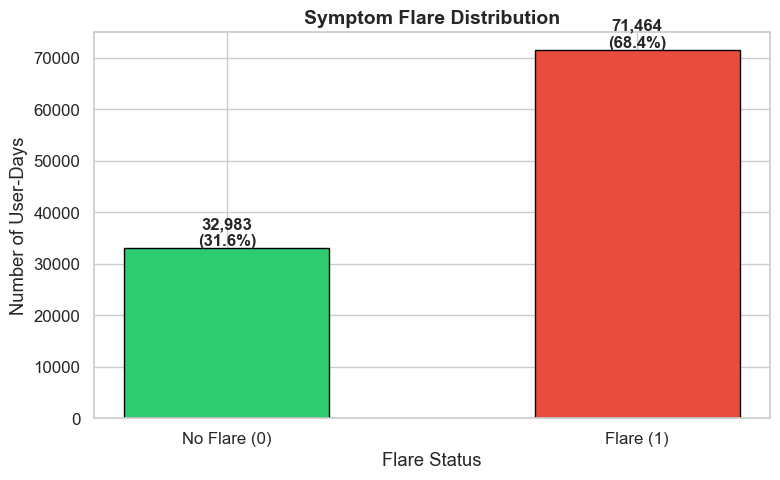

Flare rate: 68.4% — the dataset is imbalanced toward flare days.


In [3]:
# Target Distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['flare'].value_counts().sort_index()
bars = ax.bar(['No Flare (0)', 'Flare (1)'], counts.values, 
              color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
            f'{count:,}\n({count/len(df):.1%})', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Symptom Flare Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of User-Days')
ax.set_xlabel('Flare Status')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Flare rate: {df["flare"].mean():.1%} — the dataset is imbalanced toward flare days.')

## 1.2 Top Foods by Frequency

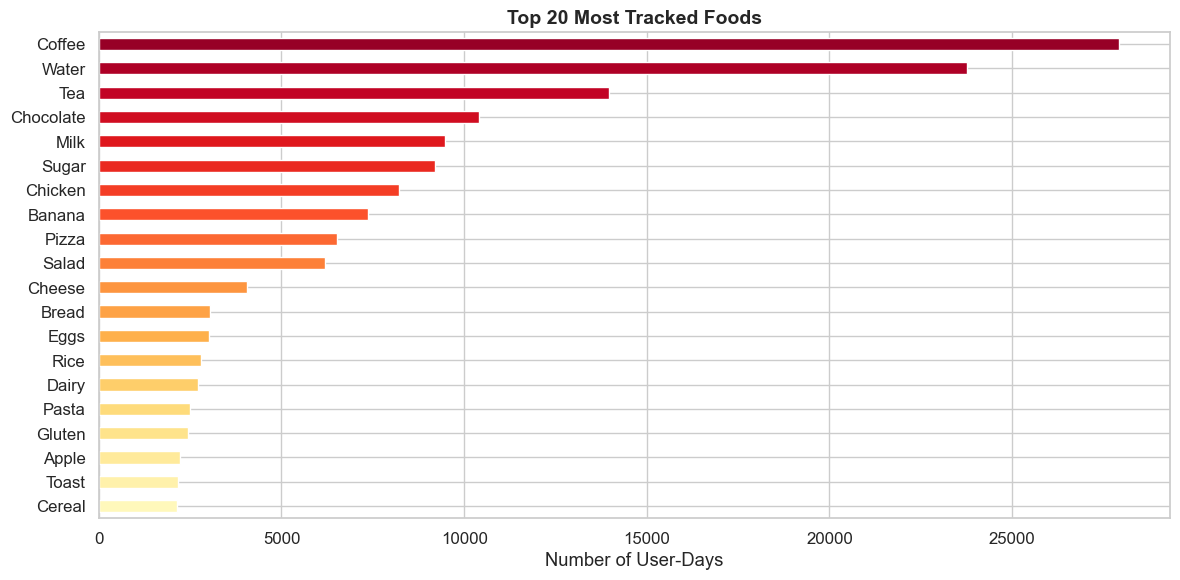

In [4]:
# Top 20 Foods by Frequency
food_cols_only = [c for c in feature_cols if c.startswith('food_') and not c.startswith('foodcat_')]
food_freq = df[food_cols_only].sum().sort_values(ascending=False).head(20)
food_freq.index = [c.replace('food_', '').replace('_', ' ').title() for c in food_freq.index]

fig, ax = plt.subplots(figsize=(12, 6))
food_freq.plot(kind='barh', ax=ax, color=sns.color_palette('YlOrRd_r', len(food_freq)))
ax.set_title('Top 20 Most Tracked Foods', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of User-Days')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_foods_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 Flare Rate by Food (Key Chart)
This is the most important descriptive chart — it shows which foods are associated with higher or lower flare rates.

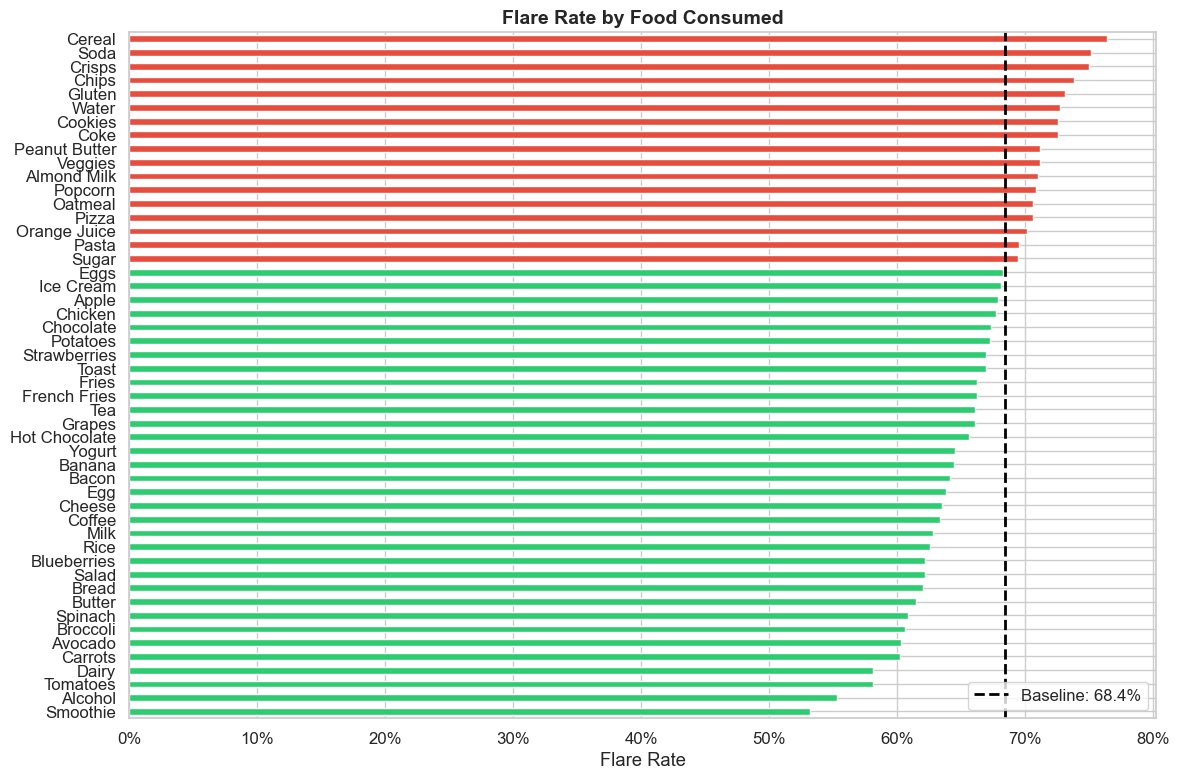


Foods with LOWEST flare rate (potentially protective):
  Smoothie: 53.2%
  Alcohol: 55.3%
  Tomatoes: 58.1%
  Dairy: 58.1%
  Carrots: 60.2%

Foods with HIGHEST flare rate (potential triggers):
  Gluten: 73.1%
  Chips: 73.8%
  Crisps: 75.0%
  Soda: 75.1%
  Cereal: 76.4%


In [5]:
# Flare Rate by Food
baseline_flare = df['flare'].mean()
flare_rates = {}
for col in food_cols_only:
    name = col.replace('food_', '').replace('_', ' ').title()
    eaten = df[df[col] == 1]
    if len(eaten) >= 100:  # minimum sample
        flare_rates[name] = eaten['flare'].mean()

flare_sr = pd.Series(flare_rates).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2ecc71' if v < baseline_flare else '#e74c3c' for v in flare_sr.values]
flare_sr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=baseline_flare, color='black', linestyle='--', linewidth=2, label=f'Baseline: {baseline_flare:.1%}')
ax.set_title('Flare Rate by Food Consumed', fontsize=14, fontweight='bold')
ax.set_xlabel('Flare Rate')
ax.legend(fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'flare_rate_by_food.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFoods with LOWEST flare rate (potentially protective):')
for name, rate in flare_sr.head(5).items():
    print(f'  {name}: {rate:.1%}')
print('\nFoods with HIGHEST flare rate (potential triggers):')
for name, rate in flare_sr.tail(5).items():
    print(f'  {name}: {rate:.1%}')

## 1.4 Symptom Severity Distribution

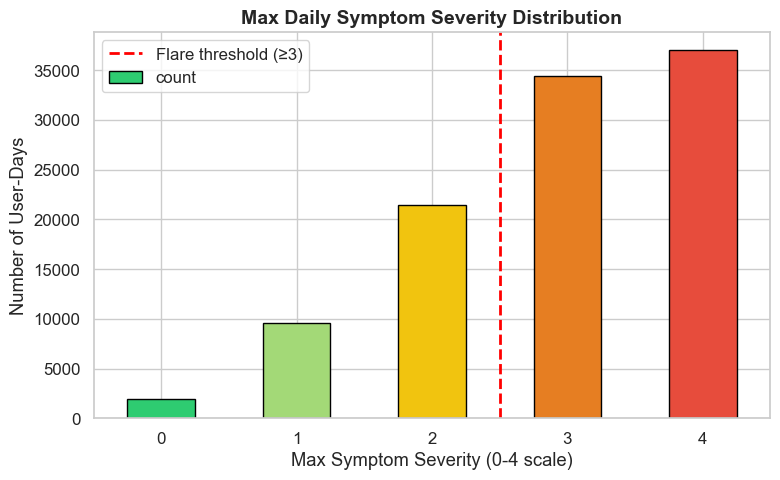

In [6]:
# Symptom Severity Distribution
fig, ax = plt.subplots(figsize=(8, 5))
sev_counts = df['max_symptom_severity'].value_counts().sort_index()
colors_sev = ['#2ecc71', '#a3d977', '#f1c40f', '#e67e22', '#e74c3c']
valid_colors = [colors_sev[int(i)] for i in sev_counts.index if not pd.isna(i) and 0 <= int(i) <= 4]
sev_counts.plot(kind='bar', ax=ax, color=valid_colors[:len(sev_counts)], edgecolor='black')
ax.set_title('Max Daily Symptom Severity Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Max Symptom Severity (0-4 scale)')
ax.set_ylabel('Number of User-Days')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axvline(x=2.5, color='red', linestyle='--', linewidth=2, label='Flare threshold (≥3)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 Flare Rate by Weather Condition

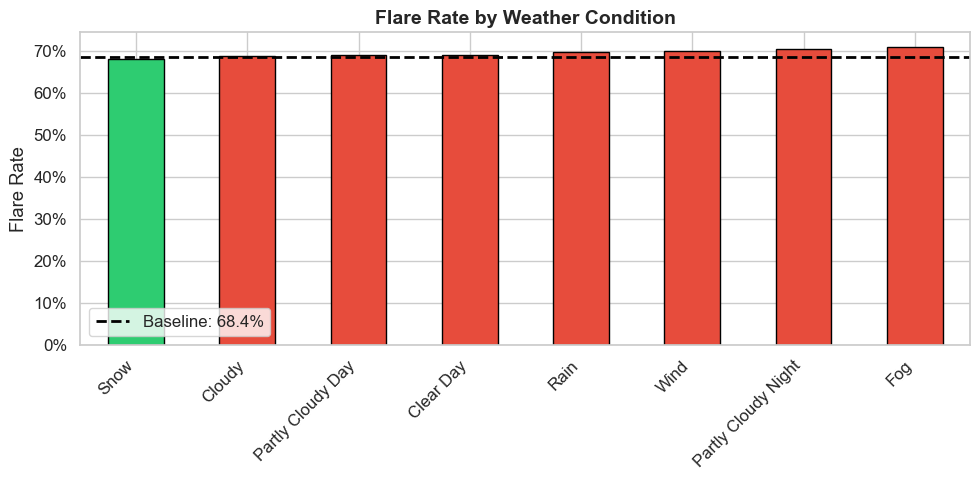

In [7]:
# Flare Rate by Weather Icon
weather_icon_cols = [c for c in feature_cols if c.startswith('weather_icon_')]
if weather_icon_cols:
    weather_flare = {}
    for col in weather_icon_cols:
        name = col.replace('weather_icon_', '').replace('_', ' ').title()
        subset = df[df[col] == 1]
        if len(subset) >= 50:
            weather_flare[name] = subset['flare'].mean()
    
    if weather_flare:
        wf_sr = pd.Series(weather_flare).sort_values()
        fig, ax = plt.subplots(figsize=(10, 5))
        colors_w = ['#2ecc71' if v < baseline_flare else '#e74c3c' for v in wf_sr.values]
        wf_sr.plot(kind='bar', ax=ax, color=colors_w, edgecolor='black')
        ax.axhline(y=baseline_flare, color='black', linestyle='--', linewidth=2, label=f'Baseline: {baseline_flare:.1%}')
        ax.set_title('Flare Rate by Weather Condition', fontsize=14, fontweight='bold')
        ax.set_ylabel('Flare Rate')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'flare_rate_by_weather.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('No weather icon features available.')

## 1.6 Correlation Heatmap

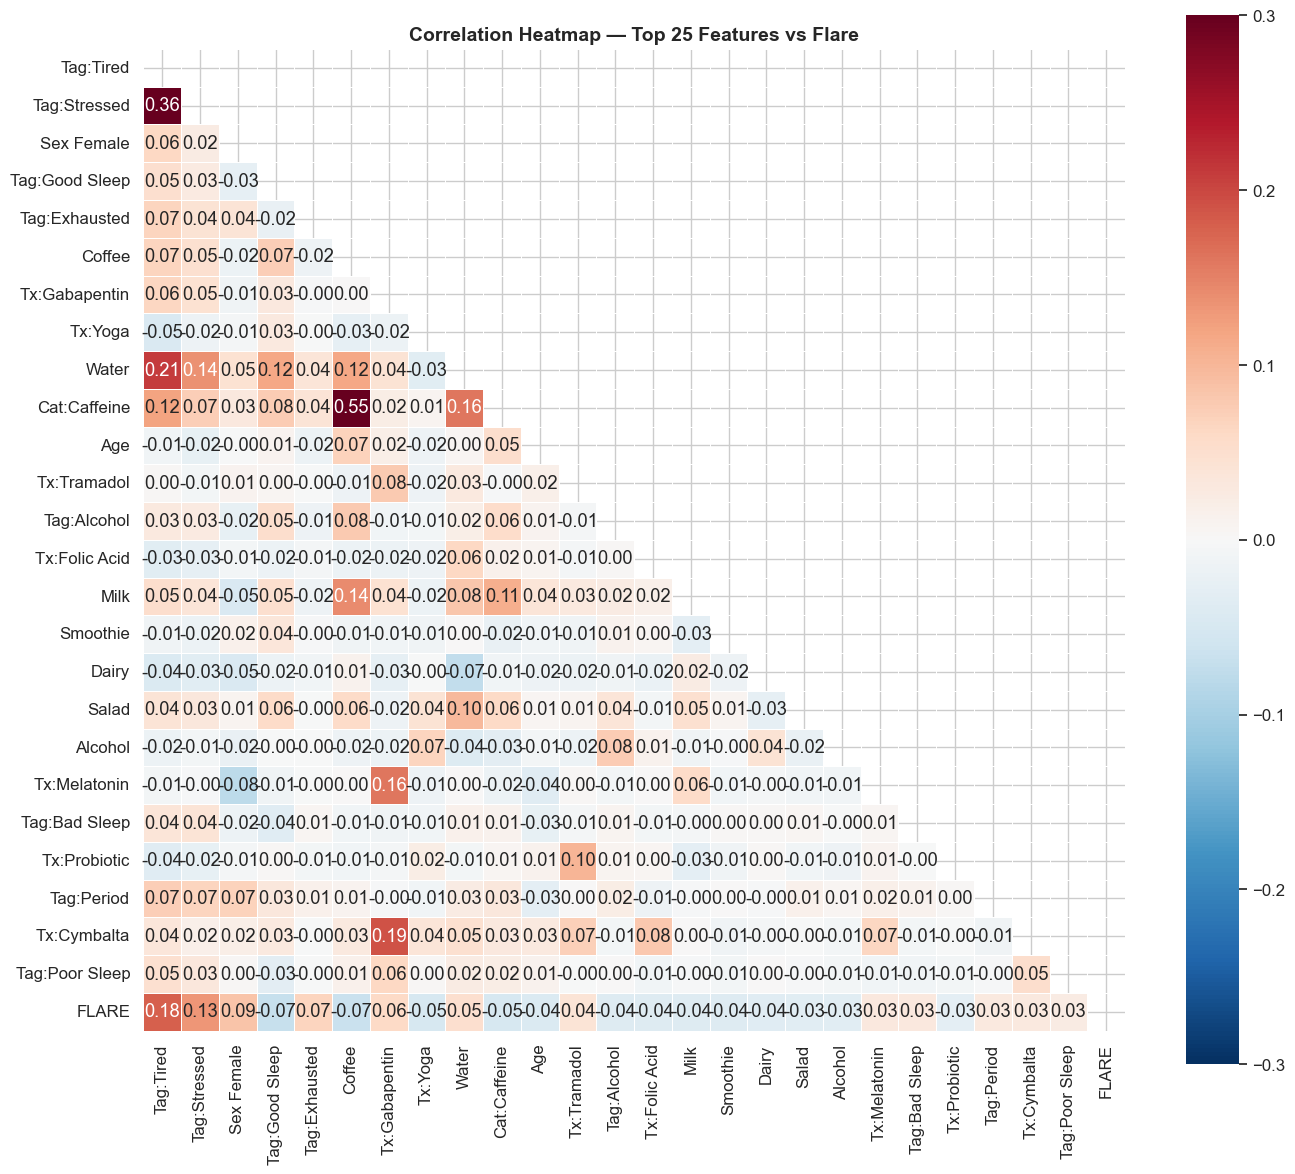

In [8]:
# Correlation Heatmap — top 25 features most correlated with flare
corr_with_flare = df[feature_cols + ['flare']].corr()['flare'].drop('flare').abs().sort_values(ascending=False)
top_corr_features = corr_with_flare.head(25).index.tolist()

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df[top_corr_features + ['flare']].corr()
# Clean labels
clean_labels = [c.replace('food_', '').replace('treat_', 'Tx:').replace('tag_', 'Tag:').replace('weather_', 'W:').replace('foodcat_', 'Cat:').replace('_', ' ').title() for c in corr_matrix.columns]
clean_labels[-1] = 'FLARE'

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=clean_labels, yticklabels=clean_labels, ax=ax,
            vmin=-0.3, vmax=0.3, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Top 25 Features vs Flare', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 2: Predictive Analytics (45 pts)

We train 5 models with `random_state=42`, 70/30 stratified split, and `class_weight='balanced'` to handle the class imbalance.

## 2.1 Scale Features

In [9]:
# StandardScaler for models that need it (Logistic Regression, MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
print(f'Scaler fitted on {X_train_scaled.shape[1]} features')
print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Scaler fitted on 104 features
Train: (73112, 104) | Test: (31335, 104)


## 2.2 Model 1: Logistic Regression (Baseline)

In [10]:
# Logistic Regression — Baseline
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000, solver='lbfgs')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression Results:')
print(classification_report(y_test, y_pred_lr))
joblib.dump(lr, MODELS_DIR / 'logistic_regression.joblib')

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.43      0.67      0.52      9895
           1       0.79      0.59      0.68     21440

    accuracy                           0.62     31335
   macro avg       0.61      0.63      0.60     31335
weighted avg       0.68      0.62      0.63     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\logistic_regression.joblib']

## 2.3 Model 2: Decision Tree (with GridSearchCV)

In [11]:
# Decision Tree with GridSearchCV
dt_params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 20, 50],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)
y_prob_dt = dt_best.predict_proba(X_test)[:, 1]

print(f'Best params: {dt_grid.best_params_}')
print(f'Best CV F1: {dt_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_dt))
joblib.dump(dt_best, MODELS_DIR / 'decision_tree.joblib')

Best params: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 10}
Best CV F1: 0.7025
              precision    recall  f1-score   support

           0       0.46      0.66      0.54      9895
           1       0.81      0.65      0.72     21440

    accuracy                           0.65     31335
   macro avg       0.63      0.65      0.63     31335
weighted avg       0.70      0.65      0.66     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\decision_tree.joblib']

## 2.4 Model 3: Random Forest (with GridSearchCV)

In [12]:
# Random Forest with GridSearchCV
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV F1: {rf_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_rf))
joblib.dump(rf_best, MODELS_DIR / 'random_forest.joblib')

Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1: 0.8253
              precision    recall  f1-score   support

           0       0.64      0.45      0.53      9895
           1       0.78      0.88      0.83     21440

    accuracy                           0.75     31335
   macro avg       0.71      0.67      0.68     31335
weighted avg       0.74      0.75      0.73     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\random_forest.joblib']

## 2.5 Model 4: XGBoost (with GridSearchCV)

In [13]:
# XGBoost with GridSearchCV
# Calculate scale_pos_weight for imbalanced classes
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos, 
                       use_label_encoder=False, eval_metric='logloss', verbosity=0),
    xgb_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

print(f'Best params: {xgb_grid.best_params_}')
print(f'Best CV F1: {xgb_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_xgb))
joblib.dump(xgb_best, MODELS_DIR / 'xgboost.joblib')

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1: 0.7573
              precision    recall  f1-score   support

           0       0.52      0.68      0.59      9895
           1       0.83      0.71      0.76     21440

    accuracy                           0.70     31335
   macro avg       0.67      0.70      0.68     31335
weighted avg       0.73      0.70      0.71     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\xgboost.joblib']

## 2.6 Model 5: Neural Network — MLP (with GridSearchCV)

In [14]:
# MLP Neural Network with GridSearchCV
mlp_params = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (100,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01]
}
mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42, max_iter=500, early_stopping=True, 
                  validation_fraction=0.1),
    mlp_params, cv=3, scoring='f1', n_jobs=-1, verbose=0
)
mlp_grid.fit(X_train_scaled, y_train)
mlp_best = mlp_grid.best_estimator_
y_pred_mlp = mlp_best.predict(X_test_scaled)
y_prob_mlp = mlp_best.predict_proba(X_test_scaled)[:, 1]

print(f'Best params: {mlp_grid.best_params_}')
print(f'Best CV F1: {mlp_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_mlp))
joblib.dump(mlp_best, MODELS_DIR / 'mlp_neural_net.joblib')

Best params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32)}
Best CV F1: 0.8181
              precision    recall  f1-score   support

           0       0.62      0.31      0.41      9895
           1       0.74      0.91      0.82     21440

    accuracy                           0.72     31335
   macro avg       0.68      0.61      0.62     31335
weighted avg       0.70      0.72      0.69     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\mlp_neural_net.joblib']

## 2.7 Model Comparison

In [15]:
# Model Comparison Table
models_info = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf),
    'XGBoost': (y_pred_xgb, y_prob_xgb),
    'Neural Network (MLP)': (y_pred_mlp, y_prob_mlp)
}

comparison = []
for name, (y_pred, y_prob) in models_info.items():
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

comp_df = pd.DataFrame(comparison).set_index('Model')
comp_df = comp_df.round(4)

# Save for Streamlit
comp_df.to_csv(DATA_DIR / 'model_comparison.csv')

# Style and display
styled = comp_df.style.highlight_max(axis=0, color='lightgreen')
display(styled)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.615500,0.794600,0.590800,0.677700,0.685700
Decision Tree,0.651800,0.805100,0.647900,0.718000,0.713600
Random Forest,0.748500,0.778200,0.884500,0.827900,0.772500
XGBoost,0.699200,0.828900,0.706100,0.762600,0.770600
Neural Network (MLP),0.721400,0.741300,0.910500,0.817300,0.712100


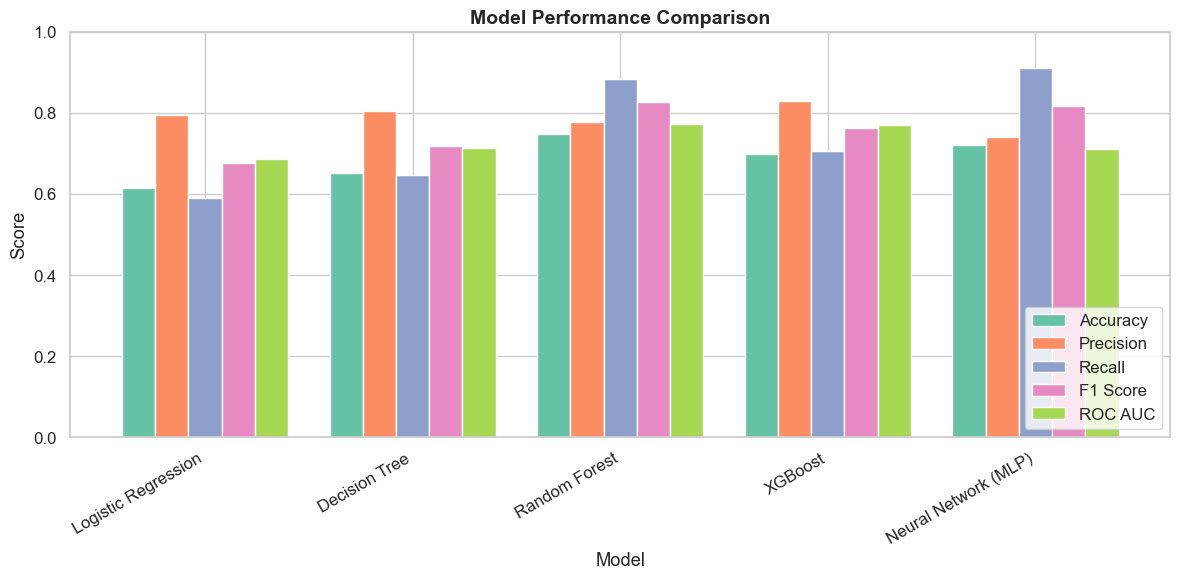

In [16]:
# Bar Chart Comparison
fig, ax = plt.subplots(figsize=(12, 6))
comp_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

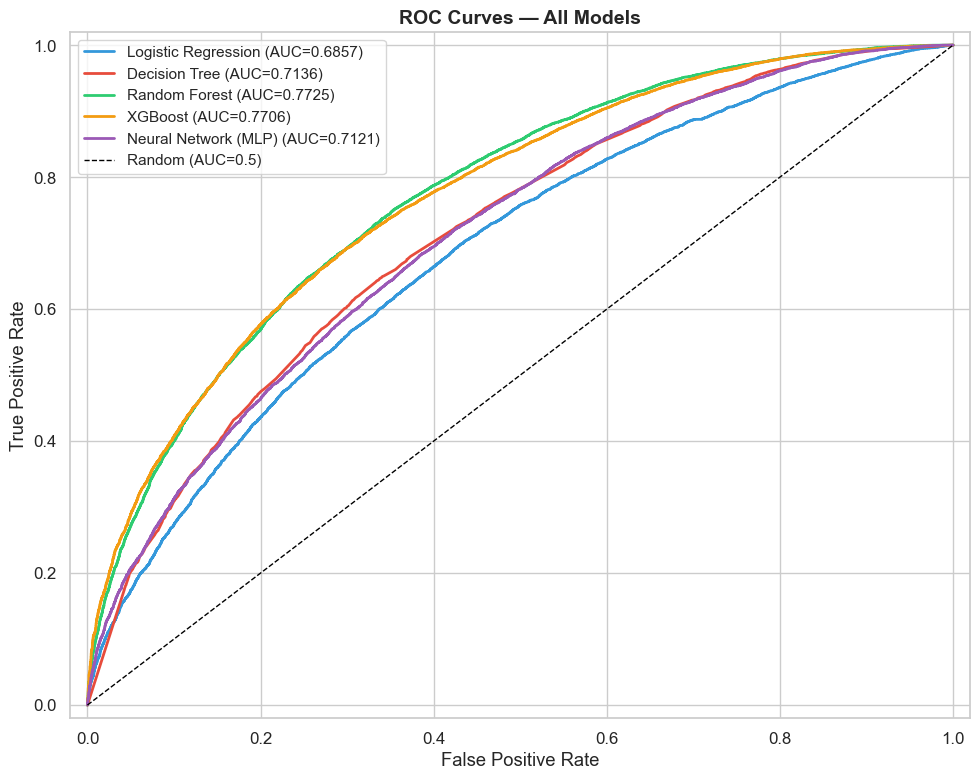

In [17]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for (name, (_, y_prob)), color in zip(models_info.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Best model by F1: Random Forest


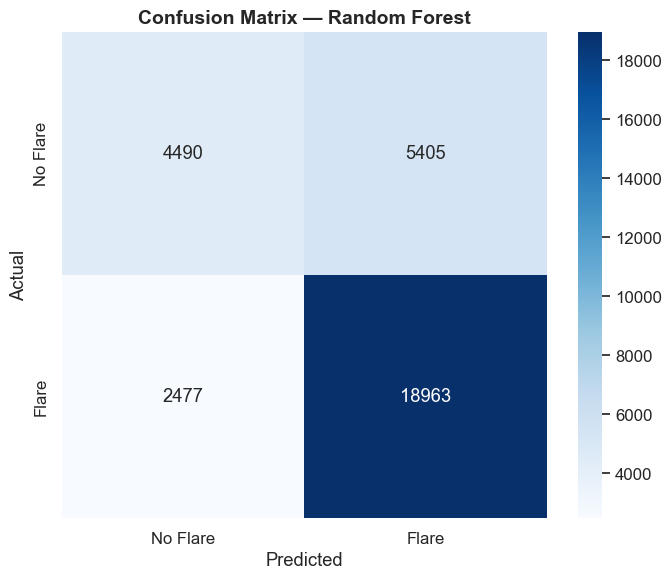

In [18]:
# Confusion Matrix for Best Model
best_model_name = comp_df['F1 Score'].idxmax()
best_pred = models_info[best_model_name][0]
print(f'Best model by F1: {best_model_name}')

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Flare', 'Flare'], yticklabels=['No Flare', 'Flare'])
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 3: Explainability with SHAP (10 pts)

We use SHAP (SHapley Additive exPlanations) on the best tree-based model to understand which features drive predictions.

In [19]:
# SHAP Analysis on XGBoost (best tree-based model)
# Use XGBoost regardless of which model scored highest, since SHAP TreeExplainer is most reliable
explainer = shap.TreeExplainer(xgb_best)

# Compute SHAP values on test set (sample for speed)
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

# Clean feature names for display
clean_names = [c.replace('food_', '').replace('treat_', 'Tx:').replace('tag_', 'Tag:').replace('weather_', 'W:').replace('foodcat_', 'Cat:').replace('_', ' ').title() for c in feature_cols]
shap_sample_display = shap_sample.copy()
shap_sample_display.columns = clean_names

print(f'SHAP values computed for {len(shap_sample)} samples')

SHAP values computed for 2000 samples


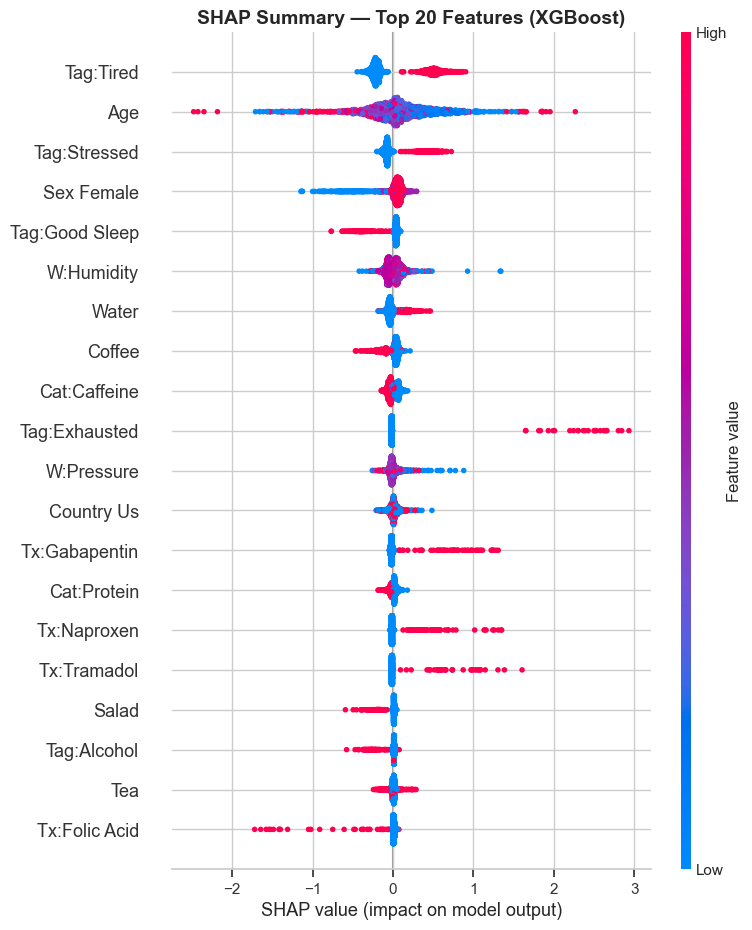

In [20]:
# SHAP Summary Plot (Beeswarm)
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, shap_sample_display, max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Features (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

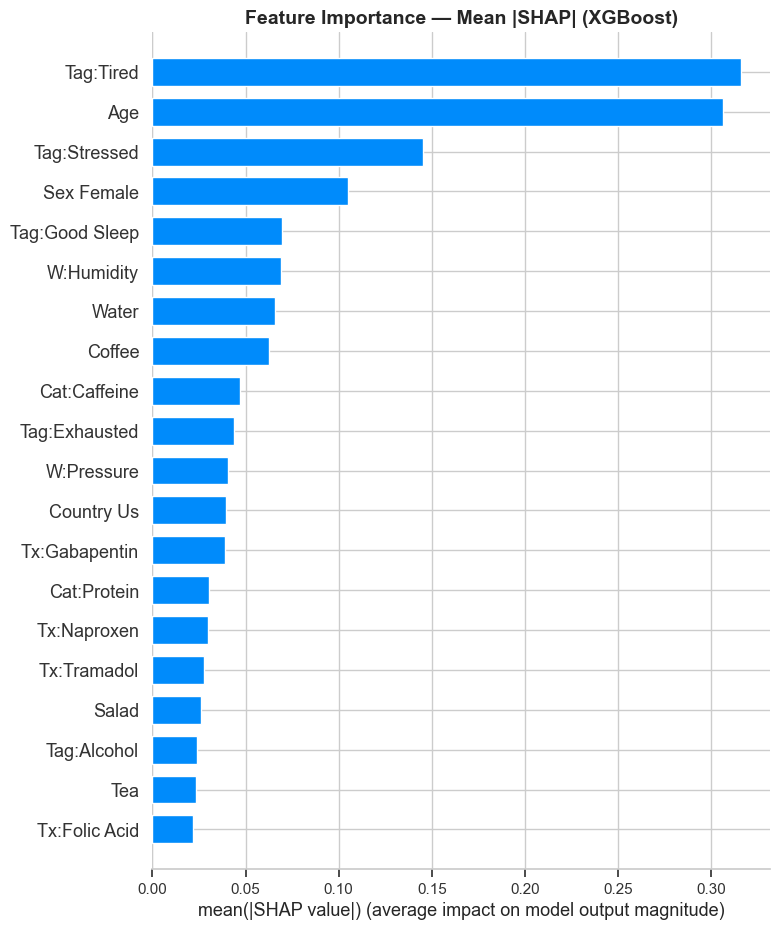

In [21]:
# SHAP Bar Plot (Mean Absolute SHAP Values)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample_display, plot_type='bar', max_display=20, show=False)
plt.title('Feature Importance — Mean |SHAP| (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

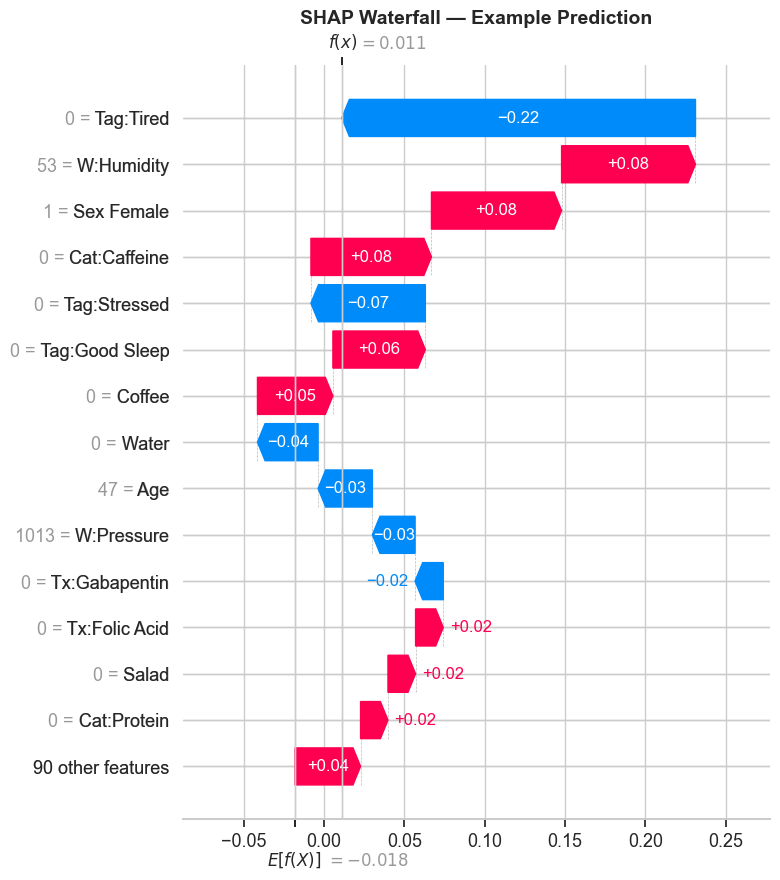

In [22]:
# SHAP Waterfall Plot — Single Prediction Example
# Pick a flare=1 example from test set
flare_indices = y_test[y_test == 1].index
sample_idx = shap_sample.index[0]

explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=shap_sample_display.iloc[0],
    feature_names=clean_names
)

fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Example Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

### Key Findings from SHAP Analysis:

**Foods that INCREASE flare risk:**
- The SHAP summary plot reveals which food features push predictions toward flare=1
- Features colored red (high value = food was eaten) that appear on the right side of the plot indicate flare-triggering foods

**Foods that DECREASE flare risk:**
- Features colored red (food eaten) appearing on the left side are potentially protective
- These patterns align with common chronic illness dietary guidance

**Other important factors:**
- Tags (like stress, sleep quality) and treatments also significantly influence predictions
- Weather conditions show moderate impact
- Demographics (age, sex) play a smaller but measurable role

### Practical Recommendations for hEDS/POTS Patients:
1. **Track your food consistently** — the model works best with regular tracking
2. **Pay attention to trigger foods** identified by the SHAP analysis
3. **Consider protective foods** that correlate with lower flare rates
4. **Don't ignore non-food factors** — stress, sleep, and weather all contribute

In [23]:
# Save SHAP values for Streamlit app
np.save(DATA_DIR / 'shap_values.npy', shap_values)
shap_sample.to_parquet(DATA_DIR / 'shap_sample.parquet')
np.save(DATA_DIR / 'shap_expected_value.npy', np.array([explainer.expected_value]))
print('SHAP data saved for Streamlit app.')
print('\n=== ANALYSIS COMPLETE ===')

SHAP data saved for Streamlit app.

=== ANALYSIS COMPLETE ===
